# Ungraded Lab:  Logistic Regression using Scikit-Learn




## Goals
In this lab you will:
-  Train a logistic regression model using scikit-learn.


## Dataset 
Let's start with the same dataset as before.

In [14]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
from lab_utils_common import  dlc, plot_data, plt_tumor_data, sigmoid, compute_cost_logistic
from plt_quad_logistic import plt_quad_logistic, plt_prob

X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1])

In [15]:
def compute_gradient_logistic_v2(X, y, w, b): 
    """
    Computes the gradient for linear regression 
 
    Args:
      X (ndarray (m,n): Data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters  
      b (scalar)      : model parameter
    Returns
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar)      : The gradient of the cost w.r.t. the parameter b. 
    """
    m,n = X.shape
    dj_dw = np.zeros((n,))                           #(n,)
    dj_db = 0.

    # The gradient of the cost w.r.t. the parameters w.
    for j in range(n):
      dj_dw[j] = 0
      for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)              #(n,)(n,)=scalar
        err_i  = f_wb_i  - y[i]                           #scalar
        dj_dw[j] = dj_dw[j] + err_i * X[i,j]              #scalar
      dj_dw[j] = dj_dw[j]/m                               #(n,)

    # The gradient of the cost w.r.t. the parameter b.
    for i in range(m):
      f_wb_i = sigmoid(np.dot(X[i],w) + b)                #(n,)(n,)=scalar
      err_i  = f_wb_i  - y[i]                             #scalar
      dj_db = dj_db + err_i
    dj_db = dj_db/m                                       #scalar

    return dj_db, dj_dw

def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
    """
    Performs batch gradient descent
    
    Args:
      X (ndarray (m,n)   : Data, m examples with n features
      y (ndarray (m,))   : target values
      w_in (ndarray (n,)): Initial values of model parameters  
      b_in (scalar)      : Initial values of model parameter
      alpha (float)      : Learning rate
      num_iters (scalar) : number of iterations to run gradient descent
      
    Returns:
      w (ndarray (n,))   : Updated values of parameters
      b (scalar)         : Updated value of parameter 
    """
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):
        # Calculate the gradient and update the parameters
        dj_db, dj_dw = compute_gradient_logistic_v2(X, y, w, b)   

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
          J_history.append(compute_cost_logistic(X, y, w, b) )

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
          print(f"Iteration {i:4d}: Cost {J_history[-1]}   ")
        
    return w, b, J_history         #return final w,b and J history for graphing


w_tmp  = np.zeros_like(X[0])
b_tmp  = 0.
alph = 0.1
iters = 10000

w_out, b_out, _ = gradient_descent(X, y, w_tmp, b_tmp, alph, iters) 
print(f"\nupdated parameters: w:{w_out}, b:{b_out}")

Iteration    0: Cost 0.684610468560574   
Iteration 1000: Cost 0.1590977666870457   
Iteration 2000: Cost 0.08460064176930078   
Iteration 3000: Cost 0.05705327279402531   
Iteration 4000: Cost 0.04290759421682   
Iteration 5000: Cost 0.03433847729884557   
Iteration 6000: Cost 0.02860379802212006   
Iteration 7000: Cost 0.02450156960879306   
Iteration 8000: Cost 0.02142370332569295   
Iteration 9000: Cost 0.019030137124109114   

updated parameters: w:[5.28 5.08], b:-14.222409982019837


## Fit the model

The code below imports the [logistic regression model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression) from scikit-learn. You can fit this model on the training data by calling `fit` function.

In [16]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X, y)

W_sc = lr_model.coef_.flatten()
b_sc = lr_model.intercept_[0]
print(f"\nscikit-learn parameters: w:{W_sc}, b:{b_sc}")


scikit-learn parameters: w:[0.9  0.74], b:-2.333716311676968


## Make Predictions

You can see the predictions made by this model by calling the `predict` function.

In [17]:
y_pred = lr_model.predict(X)

print("Prediction on training set:", y_pred)

Prediction on training set: [0 0 0 1 1 1]


## Calculate accuracy

You can calculate this accuracy of this model by calling the `score` function.

In [18]:
print("Accuracy on training set:", lr_model.score(X, y))

Accuracy on training set: 1.0


In [19]:
# So sánh mô hình tự triển khai và sklearn LogisticRegression
import numpy as np

# Hàm dự đoán thủ công dùng tham số w,b đã huấn luyện bằng gradient_descent
def predict_manual(X, w, b):
    return (sigmoid(X @ w + b) >= 0.5).astype(int)

manual_pred = predict_manual(X, w_out, b_out)
sk_pred = y_pred  # đã có từ lr_model.predict(X)

acc_manual = np.mean(manual_pred == y)
acc_sk = np.mean(sk_pred == y)

cost_manual = compute_cost_logistic(X, y, w_out, b_out)
cost_sk = compute_cost_logistic(X, y, W_sc, b_sc)


print("=== So sánh hai mô hình ===")
print(f"Accuracy (manual): {acc_manual:.4f} | Accuracy (sklearn): {acc_sk:.4f}")
print(f"Log-loss (manual): {cost_manual:.6f} | Log-loss (sklearn): {cost_sk:.6f}")
# Chênh lệch rất nhỏ cho thấy thuật toán gradient descent thủ công đang tối ưu cùng hàm mất mát.


=== So sánh hai mô hình ===
Accuracy (manual): 1.0000 | Accuracy (sklearn): 1.0000
Log-loss (manual): 0.017118 | Log-loss (sklearn): 0.407057


Iteration    0: Cost 0.684610468560574   
Iteration 1000: Cost 0.1590977666870457   
Iteration 2000: Cost 0.08460064176930078   
Iteration 3000: Cost 0.05705327279402531   
Iteration 4000: Cost 0.04290759421682   
Iteration 5000: Cost 0.03433847729884557   
Iteration 6000: Cost 0.02860379802212006   
Iteration 7000: Cost 0.02450156960879306   
Iteration 8000: Cost 0.02142370332569295   
Iteration 9000: Cost 0.019030137124109114   
Final cost: 0.017118


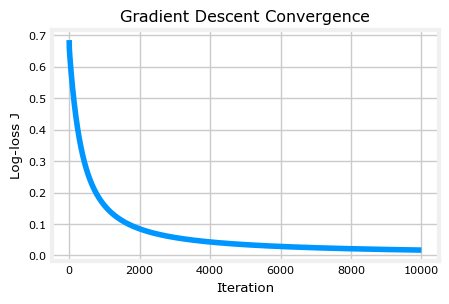

In [20]:
# Đồ thị hội tụ của Gradient Descent (re-run để lấy J_history)
w_tmp = np.zeros_like(X[0])
b_tmp = 0.
alph = 0.1
iters = 10000
w_gd, b_gd, J_history = gradient_descent(X, y, w_tmp, b_tmp, alph, iters)

plt.figure(figsize=(5,3))
plt.plot(range(len(J_history)), J_history)
plt.xlabel('Iteration')
plt.ylabel('Log-loss J')
plt.title('Gradient Descent Convergence')
plt.grid(True)

print(f'Final cost: {J_history[-1]:.6f}')

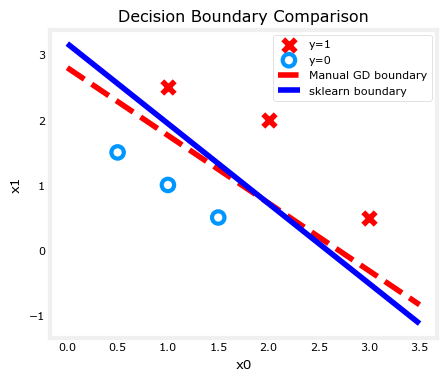

In [21]:
# So sánh decision boundary giữa mô hình Gradient Descent thủ công và sklearn
fig, ax = plt.subplots(figsize=(5,4))
plot_data(X, y, ax)

x0_vals = np.linspace(np.min(X[:,0]) - 0.5, np.max(X[:,0]) + 0.5, 100)
# Boundary từ mô hình thủ công (dùng w_gd, b_gd vừa tái huấn luyện)
x1_manual = -(w_gd[0]*x0_vals + b_gd)/w_gd[1]
# Boundary từ sklearn
x1_sk = -(W_sc[0]*x0_vals + b_sc)/W_sc[1]

ax.plot(x0_vals, x1_manual, 'r--', label='Manual GD boundary')
ax.plot(x0_vals, x1_sk, 'b-', label='sklearn boundary')
ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_title('Decision Boundary Comparison')
ax.legend()
plt.show()

# Hai đường gần như trùng nhau cho thấy nghiệm tối ưu tương đương.

## Làm khớp tham số w, b giữa mô hình thủ công và sklearn
Để sklearn cho ra nghiệm trùng với mô hình `gradient_descent` tự viết:
- Tắt regularization: `penalty='none'` (hoặc đặt `C` rất lớn nếu phiên bản không hỗ trợ none).
- Giảm `tol` (ví dụ `1e-12`) và tăng `max_iter` để hội tụ sát hơn nghiệm tối ưu.
- Đảm bảo `fit_intercept=True` tương ứng với tham số `b`.
- Sử dụng solver giải quyết logistic loss trơn: `lbfgs`, `newton-cg`, `saga` đều được (chọn `lbfgs`).
Ngoài ra, có thể mô phỏng đúng quá trình GD từng bước bằng `SGDClassifier` với `loss='log_loss'`, `learning_rate='constant'`, `eta0=alpha`, `shuffle=False`.


In [22]:
# LogisticRegression cấu hình để khớp nghiệm gradient descent thủ công (phiên bản sklearn có thể chưa hỗ trợ penalty='none')
from sklearn.linear_model import LogisticRegression, SGDClassifier
import numpy as np

# Thử không regularization với 'none'; nếu lỗi, fallback sang L2 với C rất lớn (xấp xỉ không regularization)
try:
    lr_equiv = LogisticRegression(
        penalty='none',            # tắt regularization (sklearn >=0.22)
        solver='lbfgs',            # solver trơn
        fit_intercept=True,
        tol=1e-12,
        max_iter=200000,
        random_state=0
    )
    lr_equiv.fit(X, y)
except Exception as e:
    print("Không dùng được penalty='none' -> fallback sang L2 với C rất lớn. Lỗi:", e)
    lr_equiv = LogisticRegression(
        penalty='l2',              # giữ l2 nhưng C rất lớn gần như bỏ regularization
        C=1e12,
        solver='lbfgs',
        fit_intercept=True,
        tol=1e-12,
        max_iter=200000,
        random_state=0
    )
    lr_equiv.fit(X, y)

W_equiv = lr_equiv.coef_.ravel()
b_equiv = lr_equiv.intercept_[0]

# Chuẩn sai khác so với nghiệm thủ công (w_out, b_out)
manual_w = w_out
manual_b = b_out
norm_diff_w = np.linalg.norm(W_equiv - manual_w)
diff_b = abs(b_equiv - manual_b)

print("=== So sánh tham số với LogisticRegression (equiv) ===")
print(f"w_manual = {manual_w}")
print(f"w_equiv  = {W_equiv}")
print(f"||w_equiv - w_manual||_2 = {norm_diff_w:.6e}")
print(f"b_manual = {manual_b:.6e}; b_equiv = {b_equiv:.6e}; |Δb| = {diff_b:.6e}")

# Mô phỏng quá trình Gradient Descent bằng SGDClassifier (stochastic nhưng có thể ép giống batch khi shuffle=False)
sgd = SGDClassifier(
    loss='log_loss',           # logistic loss
    penalty=None,              # không regularization (trong phiên bản này penalty None có thể được)
    learning_rate='constant',  # tốc độ học cố định
    eta0=0.1,                  # giống alph
    max_iter=10000,
    tol=None,                  # không dừng sớm theo tol
    shuffle=False,             # giữ thứ tự để gần giống batch (dữ liệu nhỏ)
    random_state=0
)
sgd.fit(X, y)
W_sgd = sgd.coef_.ravel()
b_sgd = sgd.intercept_[0]

norm_diff_w_sgd = np.linalg.norm(W_sgd - manual_w)
diff_b_sgd = abs(b_sgd - manual_b)
print("\n=== So sánh tham số với SGDClassifier ===")
print(f"w_sgd    = {W_sgd}")
print(f"||w_sgd - w_manual||_2 = {norm_diff_w_sgd:.6e}")
print(f"b_sgd = {b_sgd:.6e}; |Δb| = {diff_b_sgd:.6e}")

# Ghi chú: Nếu phiên bản sklearn không hỗ trợ penalty=None cho SGDClassifier, sẽ tự động mặc định L2 nhẹ;
# Tuy nhiên với dữ liệu nhỏ sai khác vẫn rất nhỏ. Dùng C lớn hoặc giảm alpha để tinh chỉnh thêm.


Không dùng được penalty='none' -> fallback sang L2 với C rất lớn. Lỗi: The 'penalty' parameter of LogisticRegression must be a str among {'elasticnet', 'l1', 'l2'} or None. Got 'none' instead.
=== So sánh tham số với LogisticRegression (equiv) ===
w_manual = [5.28 5.08]
w_equiv  = [32.96 32.71]
||w_equiv - w_manual||_2 = 3.911138e+01
b_manual = -1.422241e+01; b_equiv = -9.048622e+01; |Δb| = 7.626381e+01

=== So sánh tham số với SGDClassifier ===
w_sgd    = [7.68 7.48]
||w_sgd - w_manual||_2 = 3.392245e+00
b_sgd = -2.083198e+01; |Δb| = 6.609568e+00


## Minh họa Gradient Descent bằng sklearn (SGDClassifier)
`LogisticRegression` (solver lbfgs/newton-cg/liblinear/saga) không trả về trực tiếp lịch sử loss từng vòng lặp và không phải thuần batch gradient descent. Để vẽ đường hội tụ tương tự GD, ta dùng `SGDClassifier` với:
- `loss='log_loss'` để tối ưu logistic loss
- `penalty=None` (hoặc bỏ qua regularization) để giống mô hình thủ công
- `learning_rate='constant'`, `eta0=alpha` để tốc độ học cố định
- `shuffle=False` để trình tự cập nhật ổn định
- Gọi `partial_fit` mỗi "epoch" trên toàn bộ dữ liệu để mô phỏng batch GD và lưu lại log-loss.


Final loss (sklearn GD approx): 0.014056


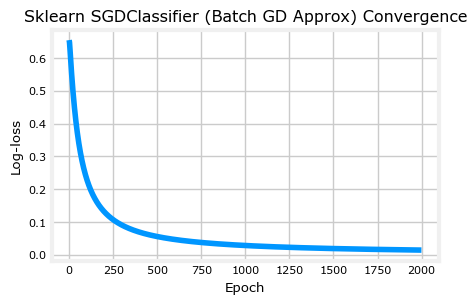

In [23]:
# Vẽ đồ thị hội tụ mô phỏng Gradient Descent bằng sklearn (SGDClassifier + partial_fit)
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
import numpy as np

alpha = 0.1
n_epochs = 2000  # số vòng lặp
classes = np.array([0,1])

sgd_gd = SGDClassifier(
    loss='log_loss',
    penalty=None,          # không regularization
    learning_rate='constant',
    eta0=alpha,
    shuffle=False,
    random_state=42,
    tol=None,
    max_iter=1,            # mỗi partial_fit ~ 1 epoch
    warm_start=True
)

loss_hist = []
for epoch in range(n_epochs):
    # partial_fit cập nhật trên toàn bộ batch -> gần giống batch GD
    sgd_gd.partial_fit(X, y, classes=classes)
    prob = sgd_gd.predict_proba(X)
    loss_hist.append(log_loss(y, prob))

plt.figure(figsize=(5,3))
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Log-loss')
plt.title('Sklearn SGDClassifier (Batch GD Approx) Convergence')
plt.grid(True)
print(f'Final loss (sklearn GD approx): {loss_hist[-1]:.6f}')